# Confidence Thresholds and Out-of-Scope Questions

A retrieval system always returns its closest answer, even when a question has nothing to do with medicine. For a medical assistant this is not acceptable, so the assistant must be able to refuse. We use the similarity of the best-matching answer, the top-1 cosine similarity, as the system's confidence and compare it with two thresholds.

| Top-1 similarity | Response |
|---|---|
| At or above the answer threshold | The retrieved human-written answer is shown. |
| Between the two thresholds | "I do not have enough reliable information about this topic in my medical knowledge base." |
| Below the scope threshold | "This question is outside the scope of this medical assistant." |

Both thresholds are chosen on validation data only and then checked once on the test data. The check covers four kinds of questions: questions from the dataset, paraphrased questions, medical questions about topics the dataset does not cover, and non-medical questions. This notebook also runs experiment E6, which tests what the user's question should be compared with, and it exports the final assistant for the web app.

In [1]:
# Work from the repository root so that `src` can be imported and the data paths resolve.
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import json, re, shutil, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

from src.config import RAW_CSV, PROCESSED_DIR, PROBE_DIR, EXTERNAL_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR, SEED, BASE_MODEL
from src.retrieval import TfidfRetriever, EmbeddingRetriever, load_knowledge_base
from src.evaluation import run_experiment, experiments_table
from src.assistant import decide, MedicalAssistant

kb = load_knowledge_base()
FINAL = json.load(open(RESULTS_DIR / "final_model_choice.json"))["final_model"]   # The final model chosen in notebook 03.
print("final fine-tuned model:", FINAL)

final fine-tuned model: models/E5_bs64_seed42


## Collecting Questions the Assistant Should Refuse

Choosing a threshold requires examples of questions that should be refused, and we wanted these to be real questions written by people rather than examples we made up. Two sources were used. The non-medical questions come from the development set of SQuAD 2.0 (Rajpurkar et al., 2018), which contains human-written questions about Wikipedia articles. We took five questions per article and left out the articles related to health or biology (Oxygen, Ctenophora, Black Death, Pharmacy and Immune system). The uncovered medical questions come from the AfriMed-QA consumer queries, which are not used anywhere else in the project. We kept only questions about diseases whose key words never appear in our knowledge base, such as psoriasis, vertigo and COVID-19.

The validation and test sides use different SQuAD articles and different diseases, so the test topics are never seen while the thresholds are chosen. The three example questions from the assignment brief are added to the test side.

In [2]:
rng = np.random.default_rng(SEED)
HEALTH_ARTICLES = {"Oxygen", "Ctenophora", "Black_Death", "Pharmacy", "Immune_system"}
GENERIC = set("and or of the in e g eg from due to related with without acute chronic disease diseases disorder "
              "disorders infection infections syndrome complications complication problems problem pain injury "
              "injuries condition conditions type severe mild general common other".split())
key_words = lambda name: [w for w in re.findall(r"[a-z]+", name.lower()) if w not in GENERIC and len(w) > 2]

def half_split(items):
    items = list(items); rng.shuffle(items)
    return set(items[: len(items) // 2])

# Non-medical questions from the SQuAD 2.0 development set.
squad_path = EXTERNAL_DIR / "squad_dev-v2.0.json"
if not squad_path.exists():
    squad_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve("https://rajpurkar.github.io/SQuAD-explorer/dataset/dev-v2.0.json", squad_path)
articles = [a for a in json.load(open(squad_path, encoding="utf-8"))["data"] if a["title"] not in HEALTH_ARTICLES]
val_titles = half_split(sorted(a["title"] for a in articles))
rows = []
for article in articles:
    questions = [qa["question"].strip() for p in article["paragraphs"] for qa in p["qas"]]
    for question in rng.choice(questions, 5, replace=False):
        rows.append({"question": question, "category": "non_medical", "source": "SQuAD 2.0 dev", "topic": article["title"],
                     "split": "val" if article["title"] in val_titles else "test"})
squad = pd.DataFrame(rows)

# Medical questions about diseases that never appear in the knowledge base.
raw = pd.read_csv(RAW_CSV)
cq = raw[raw.question_type == "consumer_queries"].copy()
cq["disease"] = cq.prompt.str.extract(r"thinks (?:she|he|they) (?:has|have) (.+?) and is going", flags=re.I)[0]
full = pd.read_csv(PROCESSED_DIR / "saq_clean.csv")
kb_words = set(re.findall(r"[a-z]+", " ".join((full.question + " " + full.answer).str.lower())))
absent = [d for d in cq.disease.dropna().unique() if key_words(d) and not any(w in kb_words for w in key_words(d))]
cq = cq[cq.disease.isin(absent)]
names_disease = np.array([any(w in q.lower() for w in key_words(d)) for q, d in zip(cq.question, cq.disease)])
cq = cq[names_disease & cq.question.str.contains(r"\?") & cq.question.str.split().str.len().between(5, 40)]
cq["question"] = cq.question.str.strip().str.strip('"').str.strip()
val_diseases = half_split(sorted(cq.disease.unique()))
rows = []
for disease, group in cq.groupby("disease"):
    for question in group.sample(min(2, len(group)), random_state=SEED).question:
        rows.append({"question": question, "category": "uncovered_medical", "source": "AfriMed-QA v2.5 consumer_queries",
                     "topic": disease, "split": "val" if disease in val_diseases else "test"})
uncovered = pd.DataFrame(rows)
print(f"diseases absent from the knowledge base: {len(absent)}")

brief = pd.DataFrame({"question": ["How do I repair my laptop?", "Who won the football match?", "How can I cook rice?"],
                      "category": "non_medical", "source": "assignment brief", "topic": "brief example", "split": "test"})
reject_val = pd.concat([squad[squad.split == "val"], uncovered[uncovered.split == "val"]], ignore_index=True)
reject_test = pd.concat([squad[squad.split == "test"], uncovered[uncovered.split == "test"], brief], ignore_index=True)
reject_val.to_csv(PROBE_DIR / "reject_val.csv", index=False)
reject_test.to_csv(PROBE_DIR / "reject_test.csv", index=False)
display(pd.concat([reject_val.assign(side="val"), reject_test.assign(side="test")])
        .groupby(["side", "category"]).agg(questions=("question", "size"), topics=("topic", "nunique")))
pd.concat([reject_val.groupby("category").sample(3, random_state=1), brief])[["category", "topic", "question"]]

diseases absent from the knowledge base: 63


questions  topics
side category                            
test non_medical               78      16
     uncovered_medical         58      30
val  non_medical               75      15
     uncovered_medical         58      29

,category,topic,question
19,non_medical,"Fresno,_California",Who preferred the Brookhaven section?
55,non_medical,Prime_number,"Other than 7 and 13, what other year interval do cicadas pupate?"
10,non_medical,European_Union_law,What was developed in the 1980's by the social partners representatives?
108,uncovered_medical,Otoplasty complications,What are the risk factors of otoplasty complications?
91,uncovered_medical,Dyspepsia,Are there any specific dietary or lifestyle changes I can make to manage my dyspepsia symptoms and improve my digest...
131,uncovered_medical,Vitiligo,"Dr, is vitiligo due to sun rays exposure or due to skin care products?"
0,non_medical,brief example,How do I repair my laptop?
1,non_medical,brief example,Who won the football match?
2,non_medical,brief example,How can I cook rice?


The search found 63 diseases in the consumer queries whose key words never appear in the knowledge base. After sampling, the validation side contains 75 non-medical questions from 15 articles and 58 uncovered medical questions about 29 diseases. The test side contains 75 non-medical questions from 15 other articles plus the three brief examples, and 58 uncovered medical questions about 30 other diseases. The questions that should be answered are the validation or test questions themselves, together with the 20 paraphrases on each side, which are loaded below.

In [3]:
paraphrases = pd.read_csv(PROBE_DIR / "paraphrases.csv")
print("paraphrases:", paraphrases.split.value_counts().to_dict())
paraphrases[["split", "original_question", "paraphrase"]].groupby("split").head(3)

paraphrases: {'val': 20, 'test': 20}


,split,original_question,paraphrase
0,val,What is the primary cause of endemic goiter in Africa?,Why do so many people in parts of Africa develop a swollen thyroid in the neck?
1,val,How does access to clean water impact health outcomes in rural Africa?,"In African villages, what difference does having safe drinking water make to people's health?"
2,val,How can traditional dance and physical activity be used to promote health and well-being in African communities?,Can dancing and staying active the traditional way help African communities stay healthy?
20,test,Infectious complications of Atopic Dermatitis,What infections can people with eczema easily get on their skin?
21,test,Differential diagnosis for goitres,What other conditions can be mistaken for a goitre?
22,test,tumour markers for colon cancer:,Which blood tests are used to follow up bowel cancer?


## Testing What the Question Is Compared With (E6)

Up to this point, the user's question has been compared only with the answers in the knowledge base. The project requirements, however, stress reworded questions: when a user rephrases a question that already exists in the dataset, the assistant should find it. Comparing the user's question with the dataset questions as well might help, so experiment E6 tests two alternatives. In the first, the question is compared with each record's dataset question and with its answer, and the higher similarity is kept. In the second, each record is stored as a single text that combines its question and answer.

When the dataset questions are used, each held-out validation or test question has its own copy hidden, since it would otherwise simply find itself. Nothing is hidden for the paraphrased questions, which matches the situation of a real user rewording a question from the dataset.

In [4]:
answers, kb_questions = kb.answer.tolist(), kb.question.tolist()
run_experiment("E6a_pretrained_both", EmbeddingRetriever(BASE_MODEL, answers, kb_questions=kb_questions), kb,
               "Pretrained model, compared with dataset questions and answers (higher similarity kept)",
               method="embedding", model=BASE_MODEL, index="both")
run_experiment("E6b_final_both", EmbeddingRetriever(str(FINAL), answers, kb_questions=kb_questions), kb,
               "Final fine-tuned model, compared with dataset questions and answers (higher similarity kept)",
               method="embedding", model=FINAL, index="both")

final_name = FINAL.split("/")[-1]
rows = []
for name, label in [("E2_pretrained", "pretrained, answers only"), ("E6a_pretrained_both", "pretrained, questions and answers"),
                    (final_name, "fine-tuned, answers only"), ("E6b_final_both", "fine-tuned, questions and answers")]:
    d = RESULTS_DIR / "experiments" / name
    val = pd.read_csv(d / "predictions_val.csv"); test = pd.read_csv(d / "predictions_test.csv")
    para = pd.read_csv(d / "predictions_paraphrase.csv")
    rows.append({"setting": label, "val R@1": val.correct_at_1.mean(),
                 "val-side paraphrases R@1 (20)": para[para.source_split == "val"].correct_at_1.mean(),
                 "test R@1": test.correct_at_1.mean(),
                 "test-side paraphrases R@1 (20)": para[para.source_split == "test"].correct_at_1.mean()})
e6 = pd.DataFrame(rows).round(3)
e6

,setting,val R@1,val-side paraphrases R@1 (20),test R@1,test-side paraphrases R@1 (20)
0,"pretrained, answers only",0.624,0.55,0.316,0.40
1,"pretrained, questions and answers",0.227,0.60,0.226,0.75
2,"fine-tuned, answers only",0.766,0.55,0.285,0.35
3,"fine-tuned, questions and answers",0.383,0.60,0.189,0.70


In [5]:
# Held-out questions would find themselves inside the combined text, so only paraphrases are scored.
from sentence_transformers import SentenceTransformer
from src.retrieval import gold_ranks
from src.evaluation import load_queries
para_q, _ = load_queries("paraphrase")
gold = para_q.answer.map({a: i for i, a in enumerate(kb.answer)}).to_numpy()
rows = []
for label, name in [("pretrained", BASE_MODEL), ("fine-tuned", FINAL)]:
    model = SentenceTransformer(str(name), device="cpu"); model.max_seq_length = 512
    enc = lambda texts: model.encode(list(texts), normalize_embeddings=True, show_progress_bar=False, batch_size=64)
    ranks = gold_ranks(enc(para_q.question) @ enc(kb.question + " " + kb.answer).T, gold)
    rows.append({"setting": f"{label}, question and answer as one text",
                 **{f"{side}-side paraphrases R@1 (20)": float((ranks[(para_q.source_split == side).to_numpy()] == 1).mean())
                    for side in ["val", "test"]}})
pd.DataFrame(rows).round(3)

,setting,val-side paraphrases R@1 (20),test-side paraphrases R@1 (20)
0,"pretrained, question and answer as one text",0.45,0.55
1,"fine-tuned, question and answer as one text",0.65,0.65


The three options show a clear trade-off. For the fine-tuned model, the results were as follows.

| Compared with | Held-out validation Recall@1 | Validation-side paraphrases | Test-side paraphrases |
|---|---|---|---|
| Answers only | 0.766 | 0.55 | 0.35 |
| Dataset questions and answers, higher score kept | 0.383 | 0.60 | 0.70 |
| Question and answer stored as one text | Not measurable | 0.65 | 0.65 |

Comparing the user's question with the dataset questions helped the paraphrased questions, especially on the test side, where the expert answers are short and the dataset question carries most of the topic. At the same time, it halved the accuracy on the held-out validation questions, whose own copy was hidden. Many dataset questions share the same template, such as "What is the leading cause of ... in Nigeria?" and "What is the second leading cause of ... in Nigeria?", so matching one question against another often picks the wrong sibling. Storing the question and answer as one text gave the most balanced paraphrase results, but it cannot be measured on held-out questions, because each question would appear inside its own stored text.

We kept the answers-only option, and the decision rests on validation evidence alone. It is the only option that could be measured on the 141 held-out validation questions, where it was far ahead, while on the 20 validation-side paraphrases the options differ by only one or two questions. The larger gain on the test-side paraphrases is reported but not used for the decision, because choosing on test data would turn the test set into a tuning set. Combining the approaches, for example by storing questions and answers together and adding a re-ranking step, is left as future work, and notebook 05 shows a concrete failure that such a combination might fix.

## Choosing the Thresholds

With the comparison method fixed, we can choose the thresholds. For every candidate value from 0.00 to 1.00 in steps of 0.01, we measure how many answerable validation questions would be answered and how many of the questions that should be refused would be refused. The answer threshold is the value with the highest balanced accuracy, the average of these two rates, which gives both groups equal weight even though they differ in size. The scope threshold is then chosen below it as the value that best separates the non-medical questions from the uncovered medical questions. When several values give the same score, we take the middle one, since it is the least sensitive to small changes in the scores.

In [6]:
CATEGORIES = ["in_domain", "paraphrase", "uncovered_medical", "non_medical"]
SHOULD_ANSWER = {"in_domain", "paraphrase"}
CANDIDATES = np.round(np.arange(0.0, 1.0001, 0.01), 2)


def load_questions(side):
    records = pd.read_csv(PROCESSED_DIR / "saq_clean.csv")
    saq = pd.read_csv(PROCESSED_DIR / f"{side}.csv")
    saq = pd.DataFrame({"question": saq.question, "category": "in_domain", "correct_answer": saq.answer})
    para = paraphrases[paraphrases.split == side].merge(records[["id", "answer"]], on="id")
    para = pd.DataFrame({"question": para.paraphrase, "category": "paraphrase", "correct_answer": para.answer})
    reject = pd.read_csv(PROBE_DIR / f"reject_{side}.csv")[["question", "category"]]
    return pd.concat([saq, para, reject], ignore_index=True)


def score_questions(retriever, df):
    scores = retriever.scores(df.question.tolist())
    top1 = scores.argmax(axis=1)
    out = df.copy()
    out["score"] = scores.max(axis=1).round(4)
    out["matched_question"] = kb.question.to_numpy()[top1]
    out["retrieved_answer"] = kb.answer.to_numpy()[top1]
    out["retrieval_correct"] = out.retrieved_answer == out.correct_answer   # This is False for questions that have no correct answer.
    return out


def middle_of_best(candidates, values):
    best = candidates[np.isclose(values, values.max())]
    return float(best[len(best) // 2])


def sweep(df):
    answerable = df.category.isin(SHOULD_ANSWER)
    rows = []
    for t in CANDIDATES:
        accepted = df.score >= t
        rows.append({"threshold": t,
                     "answerable accepted": (accepted[answerable]).mean(),
                     "answerable answered correctly": (accepted & df.retrieval_correct)[answerable].mean(),
                     "should-reject rejected": (~accepted[~answerable]).mean(),
                     "non-medical rejected": (~accepted[df.category == "non_medical"]).mean(),
                     "uncovered medical rejected": (~accepted[df.category == "uncovered_medical"]).mean()})
    table = pd.DataFrame(rows)
    table["balanced accuracy"] = (table["answerable accepted"] + table["should-reject rejected"]) / 2
    return table.round(3)


def choose_thresholds(val_df):
    table = sweep(val_df)
    answer_t = middle_of_best(table.threshold.to_numpy(), table["balanced accuracy"].to_numpy())
    rejected = val_df[val_df.category.isin(["non_medical", "uncovered_medical"])]
    candidates = CANDIDATES[CANDIDATES <= answer_t]
    bal = [((rejected.score[rejected.category == "non_medical"] < t).mean()
            + (rejected.score[rejected.category == "uncovered_medical"] >= t).mean()) / 2 for t in candidates]
    return answer_t, middle_of_best(candidates, np.array(bal)), table


def report(df):
    rows = {}
    for category in CATEGORIES:
        part = df[df.category == category]
        row = {"questions": len(part)}
        for d in ["answer", "not_enough_information", "outside_scope"]:
            row[d] = (part.decision == d).mean()
        if category in SHOULD_ANSWER:
            row["answered correctly"] = ((part.decision == "answer") & part.retrieval_correct).mean()
            row["answered wrongly"] = ((part.decision == "answer") & ~part.retrieval_correct).mean()
        rows[category] = row
    return pd.DataFrame(rows).T.round(3)

In [7]:
final_retriever = EmbeddingRetriever(str(FINAL), kb.answer.tolist())
val_scored = score_questions(final_retriever, load_questions("val"))
test_scored = score_questions(final_retriever, load_questions("test"))
ANSWER_T, SCOPE_T, sweep_table = choose_thresholds(val_scored)
print(f"answer threshold = {ANSWER_T:.2f} | scope threshold = {SCOPE_T:.2f} | best validation balanced accuracy = {sweep_table['balanced accuracy'].max():.3f}")
out_dir = RESULTS_DIR / "thresholds"; out_dir.mkdir(parents=True, exist_ok=True)
sweep_table.to_csv(out_dir / "sweep_val_final.csv", index=False)
sweep_table[sweep_table.threshold.isin(np.round(np.arange(0.2, 0.81, 0.05), 2)) | (sweep_table.threshold == ANSWER_T)]

answer threshold = 0.52 | scope threshold = 0.32 | best validation balanced accuracy = 0.968


,threshold,answerable accepted,answerable answered correctly,should-reject rejected,non-medical rejected,uncovered medical rejected,balanced accuracy
20,0.20,1.000,0.739,0.068,0.120,0.000,0.534
25,0.25,1.000,0.739,0.218,0.387,0.000,0.609
30,0.30,1.000,0.739,0.414,0.733,0.000,0.707
35,0.35,0.994,0.739,0.564,0.880,0.155,0.779
40,0.40,0.988,0.739,0.714,0.933,0.431,0.851
45,0.45,0.981,0.739,0.872,1.000,0.707,0.927
50,0.50,0.957,0.733,0.947,1.000,0.879,0.952
52,0.52,0.950,0.733,0.985,1.000,0.966,0.968
55,0.55,0.932,0.720,0.992,1.000,0.983,0.962
60,0.60,0.863,0.658,1.000,1.000,1.000,0.932


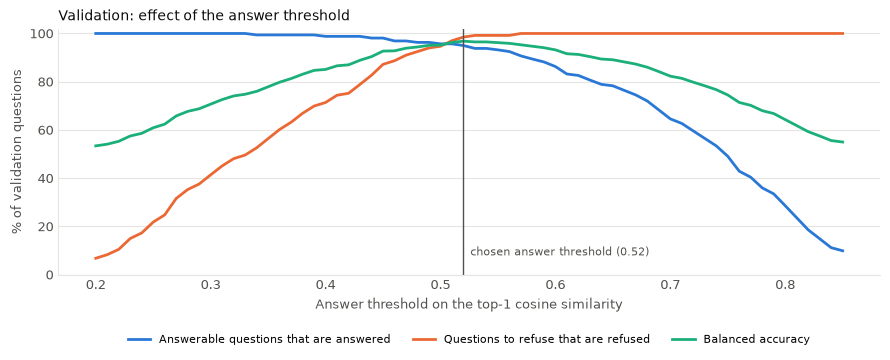

In [8]:
import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, YELLOW, LIGHT = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

def tidy(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left" if grid_axis == "x" else "top"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)

# The sweep as a chart: answering more questions also means refusing fewer of the questions that should be refused.
s = sweep_table[(sweep_table.threshold >= 0.2) & (sweep_table.threshold <= 0.85)]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(s.threshold, s["answerable accepted"] * 100, color=BLUE, linewidth=2, label="Answerable questions that are answered")
ax.plot(s.threshold, s["should-reject rejected"] * 100, color=ORANGE, linewidth=2, label="Questions to refuse that are refused")
ax.plot(s.threshold, s["balanced accuracy"] * 100, color=AQUA, linewidth=2, label="Balanced accuracy")
ax.axvline(ANSWER_T, color=INK2, linewidth=1)
ax.text(ANSWER_T + 0.006, 8, f"chosen answer threshold ({ANSWER_T:.2f})", fontsize=8, color=INK2)
ax.set_xlabel("Answer threshold on the top-1 cosine similarity", fontsize=9, color=INK2)
ax.set_ylabel("% of validation questions", fontsize=9, color=INK2)
ax.set_ylim(0, 102)
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
ax.set_title("Validation: effect of the answer threshold", loc="left", fontsize=10, color=INK)
tidy(ax, "y")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "threshold_sweep.png", dpi=200); plt.show()

The answer threshold is 0.52 and the scope threshold is 0.32, with a validation balanced accuracy of 0.968. The sweep table shows the trade-off behind this choice. A lower threshold of 0.45 would answer 98.1% of the answerable questions but would also let 12.8% of the questions that should be refused through, while a higher threshold of 0.60 would refuse all of them but answer only 86.3% of the answerable questions.

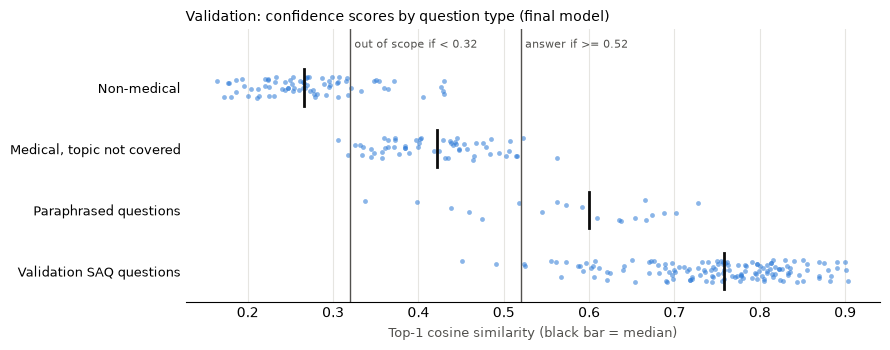

In [9]:
labels = {"in_domain": "Validation SAQ questions", "paraphrase": "Paraphrased questions",
          "uncovered_medical": "Medical, topic not covered", "non_medical": "Non-medical"}
fig, ax = plt.subplots(figsize=(9, 3.6))
jitter = np.random.default_rng(0)
for y, category in enumerate(CATEGORIES):
    s = val_scored.score[val_scored.category == category].to_numpy()
    ax.scatter(s, y + jitter.uniform(-0.18, 0.18, len(s)), s=12, color="#2a78d6", alpha=0.55, linewidths=0)
    ax.plot([np.median(s)] * 2, [y - 0.3, y + 0.3], color="#0b0b0b", linewidth=2)
for t, name in [(ANSWER_T, f"answer if >= {ANSWER_T:.2f}"), (SCOPE_T, f"out of scope if < {SCOPE_T:.2f}")]:
    ax.axvline(t, color="#52514e", linewidth=1); ax.text(t + 0.005, len(CATEGORIES) - 0.35, name, fontsize=8, color="#52514e")
ax.set_ylim(-0.5, len(CATEGORIES) - 0.05)
ax.set_yticks(range(len(CATEGORIES)), [labels[c] for c in CATEGORIES], fontsize=9)
ax.set_xlabel("Top-1 cosine similarity (black bar = median)", fontsize=9, color="#52514e")
ax.grid(axis="x", color="#e6e5e1"); ax.set_axisbelow(True)
for side in ["top", "right", "left"]: ax.spines[side].set_visible(False)
ax.tick_params(length=0)
ax.set_title("Validation: confidence scores by question type (final model)", loc="left", fontsize=10)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "threshold_scores_val.png", dpi=200); plt.show()

The figure shows why a single similarity score works reasonably well as a confidence measure. Non-medical questions sit far from every medical answer, with a median similarity of about 0.27, while the validation questions sit close to their answers, with a median of about 0.76. The uncovered medical questions fall between the two groups, which is why the middle band returns the "not enough reliable information" message. The paraphrased questions are spread more widely, and several of them fall below the answer threshold.

## Checking the Thresholds on the Test Set

The thresholds were chosen without looking at the test questions, so applying them to the test set shows how the confidence check behaves on questions and topics it has not seen.

In [10]:
for df in (val_scored, test_scored):
    df["decision"] = [decide(s, ANSWER_T, SCOPE_T) for s in df.score]
test_scored.to_csv(out_dir / "decisions_test_final.csv", index=False)
val_scored.to_csv(out_dir / "decisions_val_final.csv", index=False)
print("Test set: share of each response for each kind of question")
display(report(test_scored))
test_scored[test_scored.question.isin(brief.question)][["question", "score", "decision"]]

Test set: share of each response for each kind of question


,questions,answer,not_enough_information,outside_scope,answered correctly,answered wrongly
in_domain,354.0,0.540,0.441,0.020,0.22,0.319
paraphrase,20.0,0.700,0.300,0.000,0.35,0.350
uncovered_medical,58.0,0.052,0.931,0.017,NaN,NaN
non_medical,78.0,0.013,0.141,0.846,NaN,NaN


,question,score,decision
507,How do I repair my laptop?,0.2940,outside_scope
508,Who won the football match?,0.2582,outside_scope
509,How can I cook rice?,0.3746,not_enough_information


The confidence check refused most of the questions it should refuse: 98.7% of the non-medical test questions and 94.8% of the uncovered medical questions. All three examples from the brief were refused. "How do I repair my laptop?" and "Who won the football match?" received the out-of-scope message, while "How can I cook rice?" scored 0.37, just above the scope threshold, and therefore received the "not enough reliable information" message instead. It was still refused, although with less precise wording.

The cost of this caution appears on the expert test questions. Only 54.0% of them were answered, 22.0% correctly and 31.9% wrongly, and 44.1% received the "not enough reliable information" message. The expert questions produce lower similarity scores than the crowdsourced validation questions used to choose the thresholds, which is the same difference between the two sources that affected fine-tuning in notebook 03.

## Comparing With the TF-IDF Baseline

To see whether the embeddings also make the confidence check more reliable, we chose thresholds for the TF-IDF baseline in exactly the same way and applied them to the same test questions.

In [11]:
tfidf = TfidfRetriever(kb.answer.tolist())
val_t, test_t = score_questions(tfidf, load_questions("val")), score_questions(tfidf, load_questions("test"))
A_t, S_t, _ = choose_thresholds(val_t)
for df in (val_t, test_t):
    df["decision"] = [decide(s, A_t, S_t) for s in df.score]
test_t.to_csv(out_dir / "decisions_test_tfidf.csv", index=False)
print(f"TF-IDF thresholds: answer {A_t:.2f}, scope {S_t:.2f}")
compare = pd.DataFrame({
    "TF-IDF baseline": report(test_t)[["answer", "answered correctly"]].stack(),
    "final fine-tuned model": report(test_scored)[["answer", "answered correctly"]].stack()}).round(3)
display(compare)
test_t[test_t.question.isin(brief.question)][["question", "score", "decision"]]

TF-IDF thresholds: answer 0.18, scope 0.13


TF-IDF baseline  final fine-tuned model
in_domain         answer                        0.551                   0.540
                  answered correctly            0.141                   0.220
paraphrase        answer                        0.350                   0.700
                  answered correctly            0.000                   0.350
uncovered_medical answer                        0.259                   0.052
                  answered correctly              NaN                     NaN
non_medical       answer                        0.244                   0.013
                  answered correctly              NaN                     NaN

,question,score,decision
507,How do I repair my laptop?,0.2010,answer
508,Who won the football match?,0.0000,outside_scope
509,How can I cook rice?,0.2056,answer


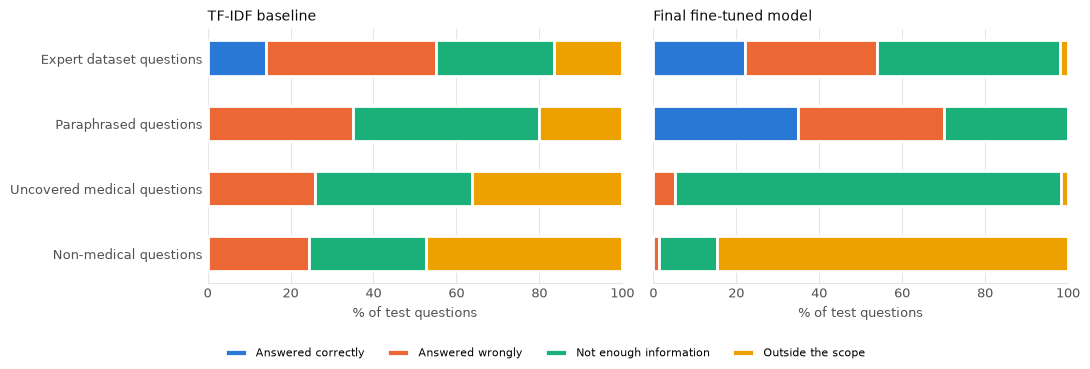

In [12]:
# How each kind of test question was handled, for the TF-IDF baseline and for the final model.
KINDS = [("in_domain", "Expert dataset questions"), ("paraphrase", "Paraphrased questions"),
         ("uncovered_medical", "Uncovered medical questions"), ("non_medical", "Non-medical questions")]

def outcome_shares(df):
    rows = {}
    for category, label in KINDS:
        part = df[df.category == category]
        answered = part.decision == "answer"
        rows[label] = {"Answered correctly": (answered & part.retrieval_correct).mean(),
                       "Answered wrongly": (answered & ~part.retrieval_correct).mean(),
                       "Not enough information": (part.decision == "not_enough_information").mean(),
                       "Outside the scope": (part.decision == "outside_scope").mean()}
    return pd.DataFrame(rows).T * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), sharey=True)
for ax, (title, frame) in zip(axes, [("TF-IDF baseline", test_t), ("Final fine-tuned model", test_scored)]):
    shares = outcome_shares(frame)
    start = np.zeros(len(shares))
    for column, color in zip(shares.columns, [BLUE, ORANGE, AQUA, YELLOW]):
        ax.barh(shares.index, shares[column], left=start, height=0.55, color=color, edgecolor="white", linewidth=2, label=column)
        start += shares[column].values
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of test questions", fontsize=9, color=INK2)
    ax.set_title(title, loc="left", fontsize=10, color=INK)
    tidy(ax, "x")
axes[0].invert_yaxis()
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, frameon=False, fontsize=8, loc="lower center", ncol=4)
fig.tight_layout(rect=(0, 0.08, 1, 1)); fig.savefig(FIGURES_DIR / "test_outcomes.png", dpi=200); plt.show()

The fine-tuned model separated answerable questions from those that should be refused much better than TF-IDF did. With TF-IDF, 24.4% of the non-medical questions and 25.9% of the uncovered medical questions were answered, compared with 1.3% and 5.2% for the final model. TF-IDF also answered "How do I repair my laptop?" and "How can I cook rice?", because its scores are compressed close to zero, so a question that shares a single ordinary word with an answer can pass the threshold. The final model also answered more questions correctly, 22.0% of the test questions against 14.1% for TF-IDF, and 35% of the test-side paraphrases against none.

## Exporting the Final Assistant

The last step prepares everything the web app needs. The diagram below summarises how the exported assistant handles one question, from cleaning to the confidence check. The folder `models/final/` then receives the fine-tuned model files, the thresholds in `assistant_config.json` and the knowledge base in `knowledge_base.csv`. The app (`app.py`, which calls `src/assistant.py`) loads only this folder, so the deployed assistant uses exactly the model and thresholds evaluated in this notebook. The export cell also runs a quick test with four questions.

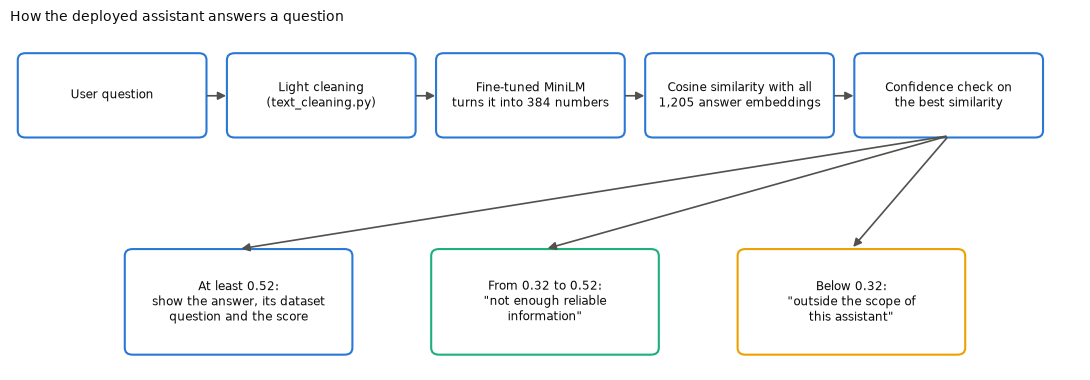

In [13]:
# A diagram of how the exported assistant answers one question.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(11, 3.9))
ax.set_xlim(0, 11); ax.set_ylim(0, 4); ax.axis("off")

def box(x, y, w, h, text, edge):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08", facecolor="white", edgecolor=edge, linewidth=1.5))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8.5, color=INK)

def arrow(x0, y0, x1, y1):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=12, color=INK2, linewidth=1.2))

steps = ["User question", "Light cleaning\n(text_cleaning.py)", "Fine-tuned MiniLM\nturns it into 384 numbers",
         "Cosine similarity with all\n1,205 answer embeddings", "Confidence check on\nthe best similarity"]
xs = [0.1, 2.25, 4.4, 6.55, 8.7]
for x, text in zip(xs, steps):
    box(x, 2.75, 1.9, 0.95, text, BLUE)
for a, b in zip(xs[:-1], xs[1:]):
    arrow(a + 1.9, 3.22, b, 3.22)
outcomes = [(1.2, "At least 0.52:\nshow the answer, its dataset\nquestion and the score", BLUE),
            (4.35, "From 0.32 to 0.52:\n\"not enough reliable\ninformation\"", AQUA),
            (7.5, "Below 0.32:\n\"outside the scope of\nthis assistant\"", YELLOW)]
for x, text, edge in outcomes:
    box(x, 0.2, 2.3, 1.2, text, edge)
    arrow(9.65, 2.75, x + 1.15, 1.42)
ax.set_title("How the deployed assistant answers a question", loc="left", fontsize=10, color=INK)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "assistant_pipeline.png", dpi=200); plt.show()

In [14]:
final_dir = MODELS_DIR / "final"
if final_dir.exists():
    shutil.rmtree(final_dir)
shutil.copytree(FINAL, final_dir)
kb[["id", "question", "answer", "tier", "country", "specialty"]].to_csv(final_dir / "knowledge_base.csv", index=False)
config = {"index": "answers", "answer_threshold": ANSWER_T, "scope_threshold": SCOPE_T,
          "trained_model": FINAL, "thresholds_chosen_on": "validation questions and validation questions that should be refused"}
json.dump(config, open(final_dir / "assistant_config.json", "w"), indent=2)
json.dump(config, open(RESULTS_DIR / "thresholds" / "final_config.json", "w"), indent=2)

assistant = MedicalAssistant(final_dir)
for q in ["How do people usually catch Ebola in Africa?", "What kills the most newborn babies in Nigeria?",
          "Is vertigo a brain problem?", "How do I repair my laptop?"]:
    r = assistant.ask(q)
    print(f"{q}\n   -> {r['decision']} (score {r['score']:.2f}): {(r.get('answer') or r.get('message'))[:120]}\n")

How do people usually catch Ebola in Africa?
   -> answer (score 0.54): Ebola virus disease is primarily transmitted through direct contact with bodily fluids of infected individuals or throug

What kills the most newborn babies in Nigeria?
   -> not_enough_information (score 0.46): I do not have enough reliable information about this topic in my medical knowledge base.

Is vertigo a brain problem?
   -> not_enough_information (score 0.39): I do not have enough reliable information about this topic in my medical knowledge base.

How do I repair my laptop?
   -> outside_scope (score 0.29): This question is outside the scope of this medical assistant. I can only answer health and medical questions.



The quick test shows the three possible responses. The Ebola question, a paraphrase of a dataset question, was answered correctly with a score of 0.54. The question about newborn deaths in Nigeria, another paraphrase, scored 0.46 and was refused even though the knowledge base contains a relevant answer, so it is one of the answerable questions lost to the threshold. The vertigo question was correctly refused as an uncovered topic, and the laptop question was refused as out of scope. Notebook 05 examines errors like these in more detail.